In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/crop_production.csv")
print(df.shape)
df.head()

(246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [4]:
df.columns
#df.describe()

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='str')

In [6]:
df.groupby('Crop')['Production'].max().sort_values(ascending=False).head(10)

Crop
Coconut           1.250800e+09
Sugarcane         3.715800e+07
Oilseeds total    7.556300e+06
Pulses total      3.632200e+06
Potato            3.530571e+06
Jute              2.589591e+06
Banana            2.390840e+06
Wheat             1.969000e+06
Cotton(lint)      1.823100e+06
Rice              1.710000e+06
Name: Production, dtype: float64

In [7]:
df["Yield"]=df["Production"]/df["Area"]

In [8]:
len(df[(df.Production==0 ) & (df.Area>0)])

3523

In [9]:
df.groupby('Crop')["Yield"].median().sort_values(ascending=False)

Crop
Sugarcane       53.241379
Coconut         43.120000
Banana          21.804276
Grapes          20.924138
Papaya          15.500000
                  ...    
Redish           0.000000
Snak Guard       0.000000
Water Melon      0.000000
other fibres     0.000000
Yam              0.000000
Name: Yield, Length: 124, dtype: float64

In [10]:
df_clean=df[df.Production!=0]
df_clean=df_clean.dropna(subset=["Production"])
df_clean.shape

(238838, 8)

In [11]:
df_clean.columns.tolist()

['State_Name',
 'District_Name',
 'Crop_Year',
 'Season',
 'Crop',
 'Area',
 'Production',
 'Yield']

In [12]:
len(df_clean[df_clean.Area==0])

0

In [13]:
import numpy as np
len(df_clean[np.isinf(df_clean.Yield)])

0

In [14]:
df_clean["Season"]=df_clean["Season"].str.strip()

In [15]:
for col in ["State_Name", "District_Name", "Season", "Crop"]:
    df_clean[col] = df_clean[col].str.strip()

In [16]:
df_clean["Season"].unique()

<StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: str

In [17]:
df_clean[df_clean.Crop == "Coconut"]["Yield"].describe()

count     1957.000000
mean      4042.468158
std       5187.276524
min          0.012658
25%          6.824752
50%         43.120000
75%       7540.029112
max      38800.000000
Name: Yield, dtype: float64

In [18]:
crops = ["Rice", "Wheat", "Maize", "Sugarcane"]
df_model = df_clean[df_clean["Crop"].isin(crops)]
print(df_model.shape)

(44490, 8)


In [19]:
df_model.groupby("Crop")["Yield"].median()

Crop
Maize         1.800000
Rice          1.938816
Sugarcane    53.286875
Wheat         1.891803
Name: Yield, dtype: float64

In [20]:
df_model[df_model.Crop == "Wheat"]["Yield"].describe()

count    7875.000000
mean        2.093076
std         1.058197
min         0.046255
25%         1.273328
50%         1.891803
75%         2.740260
max         7.461538
Name: Yield, dtype: float64

In [22]:
df_model.groupby(["Crop_Year", "Crop"])["Yield"].median().unstack()

Crop,Maize,Rice,Sugarcane,Wheat
Crop_Year,,,,
1997,1.579469,1.799813,55.366046,1.827695
1998,1.400000,1.785552,51.851274,1.911669
1999,1.572454,1.863518,54.522215,1.916599
2000,1.622517,1.712729,49.522222,1.764706
2001,1.778286,1.878604,51.952525,1.815214
2002,1.492106,1.655555,50.000000,1.688588
2003,1.714286,1.805017,49.325885,1.780745
2004,1.759002,1.666667,51.274725,1.741865
2005,1.596805,1.775424,53.787998,1.631579


In [23]:
df_model["Crop_Year"].value_counts().sort_index()

Crop_Year
1997    1950
1998    2288
1999    2339
2000    2470
2001    2380
2002    2476
2003    2546
2004    2542
2005    2495
2006    2607
2007    2741
2008    2627
2009    2561
2010    2649
2011    2533
2012    2487
2013    2436
2014    2180
2015     183
Name: count, dtype: int64

In [24]:
df_model = df_model[df_model.Crop_Year < 2015]
print(df_model.shape)

(44307, 8)


In [25]:
df_model.to_csv("../data/crop_clean.csv", index=False)

Matplotlib is building the font cache; this may take a moment.


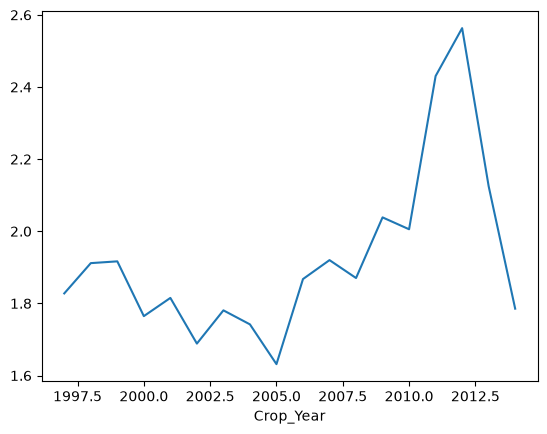

In [26]:
import matplotlib.pyplot as plt

wheat = df_model[df_model.Crop == "Wheat"]
wheat.groupby("Crop_Year")["Yield"].median().plot()
plt.show()

In [27]:
X = pd.get_dummies(
    df_model[["State_Name", "Crop_Year", "Season", "Crop", "Area"]],
    columns=["State_Name", "Season", "Crop"]
)
y = df_model["Yield"]
print(X.shape)

(44307, 45)


In [28]:
X.columns.tolist()

['Crop_Year',
 'Area',
 'State_Name_Andaman and Nicobar Islands',
 'State_Name_Andhra Pradesh',
 'State_Name_Arunachal Pradesh',
 'State_Name_Assam',
 'State_Name_Bihar',
 'State_Name_Chandigarh',
 'State_Name_Chhattisgarh',
 'State_Name_Dadra and Nagar Haveli',
 'State_Name_Goa',
 'State_Name_Gujarat',
 'State_Name_Haryana',
 'State_Name_Himachal Pradesh',
 'State_Name_Jammu and Kashmir',
 'State_Name_Jharkhand',
 'State_Name_Karnataka',
 'State_Name_Kerala',
 'State_Name_Madhya Pradesh',
 'State_Name_Maharashtra',
 'State_Name_Manipur',
 'State_Name_Meghalaya',
 'State_Name_Mizoram',
 'State_Name_Nagaland',
 'State_Name_Odisha',
 'State_Name_Puducherry',
 'State_Name_Punjab',
 'State_Name_Rajasthan',
 'State_Name_Sikkim',
 'State_Name_Tamil Nadu',
 'State_Name_Telangana',
 'State_Name_Tripura',
 'State_Name_Uttar Pradesh',
 'State_Name_Uttarakhand',
 'State_Name_West Bengal',
 'Season_Autumn',
 'Season_Kharif',
 'Season_Rabi',
 'Season_Summer',
 'Season_Whole Year',
 'Season_Winter',

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(35445, 45) (8862, 45)


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(mean_absolute_error(y_test, preds))

107.63061625171163


In [31]:
print(preds.min(), preds.max())

-319.5556276498892 981.9712560556463


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print(mean_absolute_error(y_test, rf_preds))

11.911506648088002


In [33]:
print(rf_preds.min(), rf_preds.max())

0.013596625782332117 77756.33333333333


In [34]:
results = X_test.copy()
results["actual"] = y_test
results["predicted"] = rf_preds
results["error"] = (results["actual"] - results["predicted"]).abs()
print(results.groupby(results["Crop_Sugarcane"])["error"].mean())

Crop_Sugarcane
False     0.546445
True     65.150150
Name: error, dtype: float64


In [35]:
df_model[df_model.Crop == "Sugarcane"]["Yield"].describe()

count     7786.000000
mean       195.818609
std       3152.913294
min          0.001038
25%         37.194871
50%         53.247047
75%         71.250000
max      88000.000000
Name: Yield, dtype: float64

In [36]:
len(df_model[(df_model.Crop == "Sugarcane") & (df_model.Yield > 200)])

50

In [37]:
df_model = df_model[~((df_model.Crop == "Sugarcane") & (df_model.Yield > 200))]
print(df_model.shape)

(44257, 8)


In [38]:
X = pd.get_dummies(
    df_model[["State_Name", "Crop_Year", "Season", "Crop", "Area"]],
    columns=["State_Name", "Season", "Crop"]
)
y = df_model["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print(mean_absolute_error(y_test, rf_preds))

2.0369929414301007


In [39]:
sample = X_test.iloc[[0]]
print("predicted:", rf.predict(sample))
print("actual:", y_test.iloc[0])

predicted: [1.11170881]
actual: 1.1364583333333333


In [40]:
import joblib
joblib.dump(rf, "../models/model.pkl")
joblib.dump(X.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']

In [41]:
import os
print(os.listdir("../models"))

['columns.pkl', 'model.pkl']


In [42]:
options = {
    "states": sorted(df_model.State_Name.unique()),
    "crops": sorted(df_model.Crop.unique()),
    "seasons": sorted(df_model.Season.unique()),
    "years": sorted(df_model.Crop_Year.unique()),
}
joblib.dump(options, "../models/options.pkl")

['../models/options.pkl']

In [43]:
pip install streamlit

  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.5 MB 2.4 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/10.5 MB 3.1 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/10.5 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/10.5 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/10.5 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/10.5 MB 2.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/10.5 MB 2.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/10.5 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/10.5 MB 2.2 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.5 MB 2.1 MB/s eta 0:00:03
   ------------------ ------